# Проект: Оценка рисков невозврата кредита

* Автор: Филимонова Мария
* Дата: 14.02.2026

### Цели и задачи проекта

**Цель:**   Выявить и проанализировать ключевые факторы, влияющие на своевременное погашение кредита клиентами банка.

**Задачи:**

- Загрузить данные из предоставленных источников и провести первичное знакомство с их структурой и качеством.

- Провести предобработку данных для обеспечения корректности анализа: обработать пропуски, дубликаты и преобразовать типы данных.

- Провести анализ выбросов и аномальных значений

- Создание новых признаков

- Подготовить выводы, сопроводив результаты наглядными визуализациями.

### Описание данных

В проекте будут использованы данные датасета `credit_scoring_eng.csv` с таким описанием:

- `children` — количество детей в семье;
- `days_employed` — сколько дней работает клиент;
- `dob_years` — возраст клиента;
- `education` — уровень образования клиента;
- `education_id` — идентификатор образования клиента;
- `family_status` — семейное положение клиента;
- `family_status_id` — идентификатор семейного положения клиента;
- `gender` — пол клиента;
- `income_type` — тип дохода клиента;
- `debt` — был ли у клиента когда-либо просрочен платёж по кредиту;
- `total_income` — ежемесячный доход;
- `purpose` — причина оформления кредита.

### Содержимое проекта

1. Загрузка и знакомство с данными
2. Предобработка данных
3. Выбросы и аномальные значения
4. Добавление новых столбцов в таблицу
5. Исследовательский анализ данных
6. Итоговый вывод

## 1. Загрузка и знакомство с данными:

In [1]:
# Импортируем библиотеку numpy
import numpy as np

# Импортируем библиотеку pandas
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Выгружаем данные в переменную df_raw
try:
    df_raw = pd.read_csv('/datasets/credit_scoring_eng.csv')
except FileNotFoundError:
    df_raw = pd.read_csv('C:/Users/Huawei/OneDrive/Рабочий стол/Проекты/Оценка рисков невозврата кредита/credit_scoring_eng.csv')

In [3]:
# Делаем копию исходного датафрейма
df = df_raw.copy()

In [4]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


In [5]:
# Выводим первые строки датафрейма на экран
df.head()

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,bachelor's degree,0,married,0,F,employee,0,40620.102,purchase of the house
1,1,-4024.803754,36,secondary education,1,married,0,F,employee,0,17932.802,car purchase
2,0,-5623.422610,33,Secondary Education,1,married,0,M,employee,0,23341.752,purchase of the house
3,3,-4124.747207,32,secondary education,1,married,0,M,employee,0,42820.568,supplementary education
4,0,340266.072047,53,secondary education,1,civil partnership,1,F,retiree,0,25378.572,to have a wedding


Датасет `credit_scoring_eng.csv` содержит 12 столбцов и 21525 строк, в которых представлена информация о заёмщиках: их демографические характеристики, уровень дохода, семейное положение, образование, наличие задолженности и цели кредитования.

Изучим типы данных и их корректность:

- **Целочисленные значения (int64).** Пять столбцов имеют тип данных `int64`:

    - `children` содержит информацию о количестве детей. Тип `int64` полностью соответствует смыслу данных.

    - `dob_years` содержит информацию о возрасте клиента в годах. Тип `int64` уместен, так как возраст обычно указывается целыми числами.

    - `education_id` содержит информацию о идентификаторе уровня образования. Тип `int64` логичен

    - `family_status_id` содержит информацию о идентификаторе семейного положения. Тип `int64` оправдан

    - `debt` содержит информацию о наличии задолженности (0 или 1). Тип `int64` подходит для бинарного признака.

- **Числа с плавающей точкой (float64).** Два столбца имеют тип `float64`:

    - `days_employed` содержит информацию о стаже работы в днях. Для таких данных рекомендуется использовать целочисленный тип данный (`int64`). Также возникают вопросы по поводу отрицательных значений в столбце

    - `total_income` содержит информацию об общем доходе клиента. Тип `float64` оправдан, так как доход может содержать дробную часть.

- **Строковые данные (object).** Пять столбцов имеют тип `object`:

    - `education` содержит информациб об уровне образования. Тип `object` уместен для текстового описания.

    - `family_status` содержит информацию об семейном положении. Тип `object` соответствует строковому значению.

    - `gender` содержит информацию о поле клиента. Тип `object` подходит.

    - `income_type` содержит информацию о типе дохода. Тип `object` логичен.

    - `purpose` содержит информацию о цели кредита. Тип `object` оправдан.

## 2. Предобработка данных

In [6]:
# Выводим количество пропущенных строк в датафрейме
df.isna().sum().sort_values(ascending=False)

days_employed       2174
total_income        2174
dob_years              0
children               0
education              0
education_id           0
family_status_id       0
family_status          0
gender                 0
income_type            0
debt                   0
purpose                0
dtype: int64

In [7]:
# Подсчитываем процент строк с пропусками
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

days_employed       10.099884
total_income        10.099884
dob_years            0.000000
children             0.000000
education            0.000000
education_id         0.000000
family_status_id     0.000000
family_status        0.000000
gender               0.000000
income_type          0.000000
debt                 0.000000
purpose              0.000000
dtype: float64

В данных наблюдаются пропуски в следующих столбцах:

- `days_employed`: в 2174 строках (10% данных) отсутствует информация о количестве дней, которые работал клиент. Возможно, отсутствует информация об официальном стаже (пенсионеры, безработные, студенты)
- `total_income`: в 2174 строках (10% данных) отсутствует информация о ежемесячном доходе. Возможно, доход не указан для пенсионеров, студентов (так как не работают) и безработных

Совпадение числа пропусков с высокой вероятностью указывает на то, что пропуски относятся к одним и тем же наблюдениям.

**Обработка пропусков в `days_employed`**

In [8]:
# Заменяем пропуски в days_employed на 0
df['days_employed'] = df['days_employed'].fillna(0)
print(f"Пропуски в days_employed после замены: {df['days_employed'].isna().sum()}")

Пропуски в days_employed после замены: 0


Пропуск в этом столбце логично трактовать как «нет официального трудового стажа», поэтому пропущенные значения заполним 0

**Обработка пропусков в `total_income`**

In [9]:
# Группируем по income_type и вычисляем медиану для каждой группы
median_by_income_type = df.groupby('income_type')['total_income'].transform('median')

# Заполняем пропуски в total_income соответствующими медианными значениями
df['total_income'] = df['total_income'].fillna(median_by_income_type)

# Проверяем результат
print(f"Пропуски в total_income после замены: {df['total_income'].isna().sum()}")


Пропуски в total_income после замены: 0


Заполним пропуски медианой, так как она менее чувствительна к экстремальным значениям, чем среднее.

**Уникальные значения в столбцах `education` и `gender`**

In [10]:
# Функция для вывода уникальных значений для каждого столбцах ('education', 'gender')
def unique_categorical_data(columns_data):
    # Получаем уникальные значения
    print(columns_data.upper())
    unique_val = df[columns_data].unique()
    print(f'Количество уникальных значений: {len(unique_val)}')
    print(f'Уникальные значения: {unique_val}')
    print()


columns_data = ['education', 'gender']

for coll in columns_data:
    if coll in df.columns:
        unique_categorical_data(coll)

EDUCATION
Количество уникальных значений: 15
Уникальные значения: ["bachelor's degree" 'secondary education' 'Secondary Education'
 'SECONDARY EDUCATION' "BACHELOR'S DEGREE" 'some college'
 'primary education' "Bachelor's Degree" 'SOME COLLEGE' 'Some College'
 'PRIMARY EDUCATION' 'Primary Education' 'Graduate Degree'
 'GRADUATE DEGREE' 'graduate degree']

GENDER
Количество уникальных значений: 3
Уникальные значения: ['F' 'M' 'XNA']



In [11]:
# Функция для поиска неявных дубликатов
def implicit_duplicates(columns_name):

    column_data = df[columns_name]

    original_unique = column_data.unique()
    original_count = len(original_unique)

    normalized= column_data.astype(str).str.lower().str.strip()
    normalized_unique = normalized.unique()
    normalized_count = len(normalized_unique)

    print(columns_name.upper())
    print(f'Оригинальные уникальные значения {original_count}:')
    print(f'{sorted(original_unique)}')

    print(f'Уникальные нормализованные значения {normalized_count}:')
    print(f'{sorted(normalized_unique)}')
    print()
    

    if original_count > normalized_count:
        print(f'Вывод: {original_count - normalized_count} - количество неявных дубликатов')
    else:
        print('Вывод: Неявных дубликатов нет')

    print()
    print()


columns_name = ['education', 'gender']

for coll in columns_name:
    if coll in df.columns:
        implicit_duplicates(coll)

EDUCATION
Оригинальные уникальные значения 15:
["BACHELOR'S DEGREE", "Bachelor's Degree", 'GRADUATE DEGREE', 'Graduate Degree', 'PRIMARY EDUCATION', 'Primary Education', 'SECONDARY EDUCATION', 'SOME COLLEGE', 'Secondary Education', 'Some College', "bachelor's degree", 'graduate degree', 'primary education', 'secondary education', 'some college']
Уникальные нормализованные значения 5:
["bachelor's degree", 'graduate degree', 'primary education', 'secondary education', 'some college']

Вывод: 10 - количество неявных дубликатов


GENDER
Оригинальные уникальные значения 3:
['F', 'M', 'XNA']
Уникальные нормализованные значения 3:
['f', 'm', 'xna']

Вывод: Неявных дубликатов нет




In [12]:
# Приводим значения в колонке 'education' к нижнему регистру
df['education'] = df['education'].str.lower()

In [13]:
df['education'].unique()

array(["bachelor's degree", 'secondary education', 'some college',
       'primary education', 'graduate degree'], dtype=object)

**Проверка на наличие полностью дублирующих строк**

In [14]:
# Вывод явных дубликатов
duplicates = df[df.duplicated()]
print("Дублирующиеся строки:")
print(duplicates)

Дублирующиеся строки:
       children  days_employed  dob_years            education  education_id  \
2849          0            0.0         41  secondary education             1   
3290          0            0.0         58  secondary education             1   
4182          1            0.0         34    bachelor's degree             0   
4851          0            0.0         60  secondary education             1   
5557          0            0.0         58  secondary education             1   
...         ...            ...        ...                  ...           ...   
20702         0            0.0         64  secondary education             1   
21032         0            0.0         60  secondary education             1   
21132         0            0.0         47  secondary education             1   
21281         1            0.0         30    bachelor's degree             0   
21415         0            0.0         54  secondary education             1   

           family

In [15]:
# Сумма явных дубликатов
df.duplicated().sum()

np.int64(71)

In [16]:
# Удаляем полные дубликаты
df_drop_afret_1 = df.drop_duplicates(inplace=True)

# Вывод размера датафрейма после удаления полных дубликатов
display(df.shape)

(21454, 12)

**Промежуточные выводы**

**1. Явные дубликаты:**

- Полные дубликаты: найдено 54 строки

**2. Неявные дубликаты:**

2.1. Уровень образования клиента (`education`):

- Обнаружено: 10 неявных дубликатов из 15 уникальных значений

2.2. Пол клиента (`gender`):

- Обнаружено: 0 неявных дубликатов
- Уникальных значений: 3 (одинаково до и после нормализации)

**3. Действия по обработке явных дубликатов:**

- Полные дубликаты: Удалены все полностью идентичные строки, оставлена первая встретившаяся запись

**4. Действия по обработке неявных дубликтов:**

4.1. Для уровеня образования клиентов (`education`):

- Приведены все значения к нижнему регистру 
- Устранены 10 неявных дубликатов

4.2. Для пола клиента (`gender`):

- Неявных дубликатов не обнаружено, поэтому нормализация не требовалась

## 3. Выбросы и аномальные значения

In [17]:
print("Базовые статистики:")
print(df[['total_income', 'dob_years', 'children']].describe())

Базовые статистики:
        total_income     dob_years      children
count   21454.000000  21454.000000  21454.000000
mean    26451.212929     43.271231      0.539946
std     15709.968189     12.570822      1.383444
min      3306.762000      0.000000     -1.000000
25%     17219.817250     33.000000      0.000000
50%     22815.103500     42.000000      0.000000
75%     31331.348000     53.000000      1.000000
max    362496.645000     75.000000     20.000000


**Анализ столбца `total_income`**

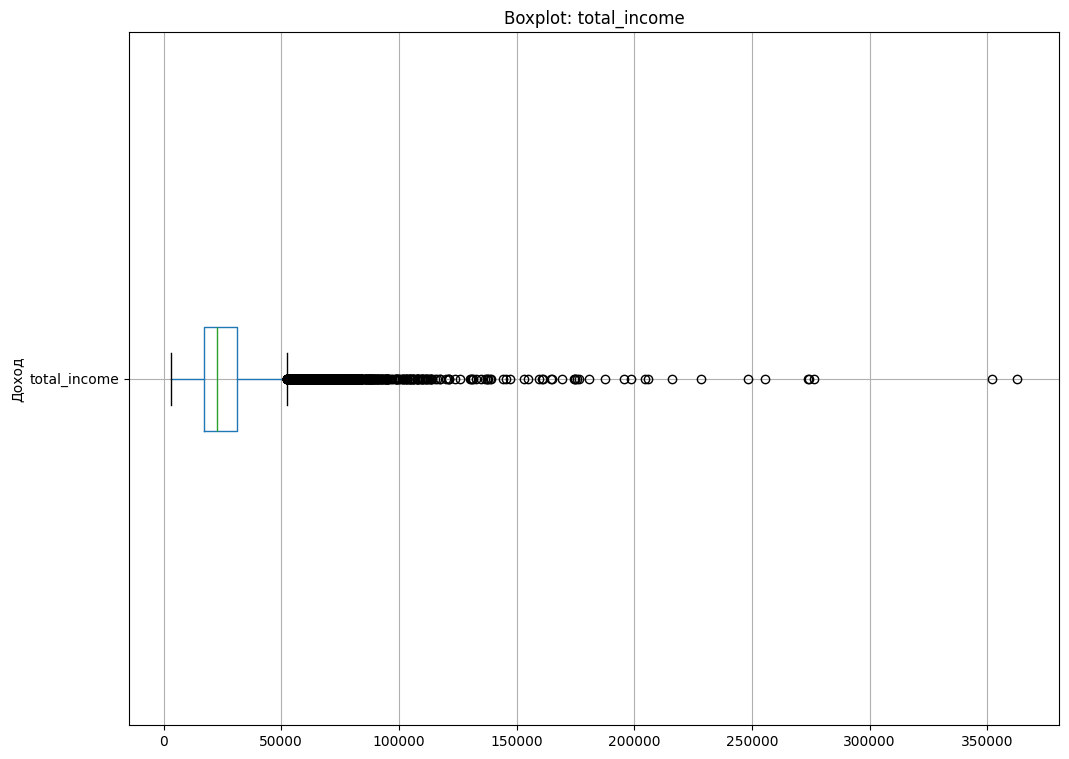

In [18]:
# Задаем размер графика
plt.figure(figsize=(12, 9))

# Строим график "ящик с усами"
df.boxplot(column='total_income',
           vert=False,
           grid=True
           )

# Настраиваем оформление графика
plt.title('Boxplot: total_income')
plt.ylabel('Доход')

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Медиана находится близко к нижней границе ящика — это признак правосторонней асимметрии распределения

- Большинство значений сконцентрировано в нижней части диапазона, а высокие доходы — редкие случаи

- За верхним усом видно множество точек — выбросы, то есть значения, значительно превышающие типичный диапазон доходов

- Выбросы разбросаны в диапазоне от 120 000 до 350 000 и более — это клиенты с существенно более высокими доходами по сравнению с основной массой

In [19]:
Q1 = df['total_income'].quantile(0.25)
Q3 = df['total_income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1:,.2f}')
print(f'Q3: {Q3:,.2f}')
print(f'IQR: {IQR:,.2f}')
print(f'Нижняя граница выбросов: {lower_bound:,.2f}')
print(f'Верхняя граница выбросов: {upper_bound:,.2f}')

outliers = df[(df['total_income'] < lower_bound) | (df['total_income'] > upper_bound)]
print(f'Количество выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')


Q1: 17,219.82
Q3: 31,331.35
IQR: 14,111.53
Нижняя граница выбросов: -3,947.48
Верхняя граница выбросов: 52,498.64
Количество выбросов: 1120 (5.22%)


### Решение по выбросам в столбце `total_income`:

Не удалять выбросы, так как эти значения не являются техническими ошибками или аномалиями — они отражают реальных заёмщиков с высоким уровнем дохода.

**Анализ столбца `dob_years`**

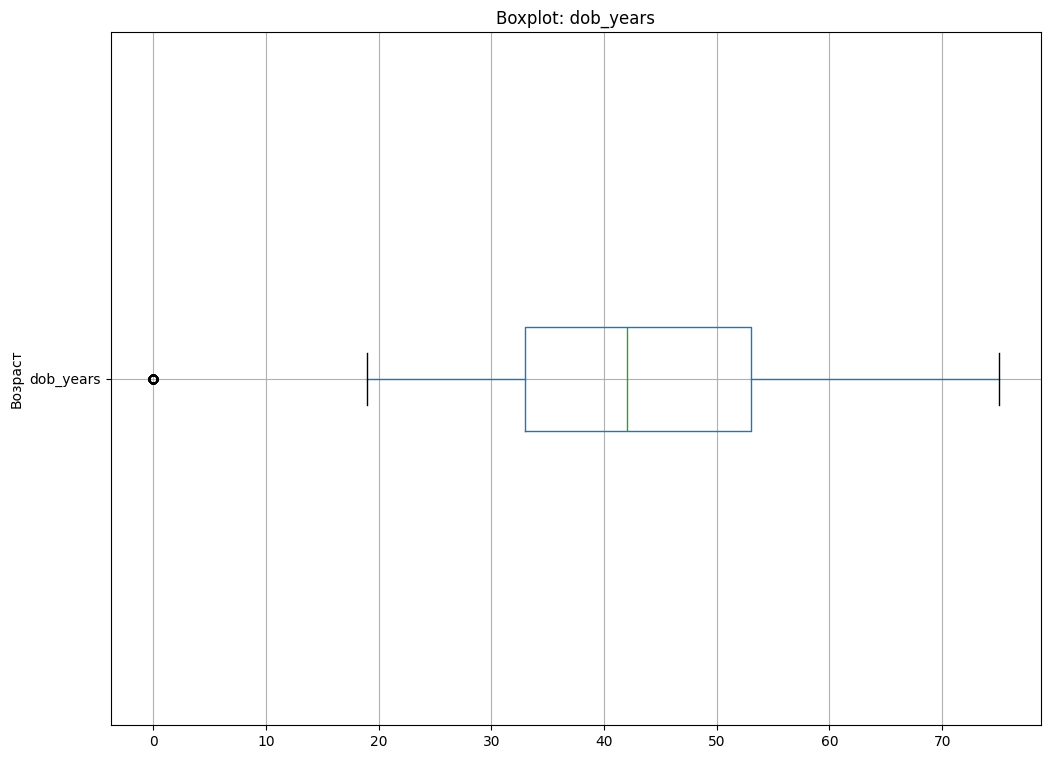

In [20]:
# Задаем размер графика
plt.figure(figsize=(12, 9))

# Строим график "ящик с усами"
df.boxplot(column='dob_years',
           vert=False,
           grid=True
           )

# Настраиваем оформление графика
plt.title('Boxplot: dob_years')
plt.ylabel('Возраст')

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Медиана расположена относительно близко к нижней границе ящика, что указывает на правостороннюю асимметрию распределения возраста. Это означает, что большая часть выборки сосредоточена в более молодом возрастном диапазоне

- За нижним усом виден один явный выброс — это значение существенно ниже основного диапазона. Вероятно, это ошибка ввода данных

- Выбросов за верхним усом не наблюдается

- В целом распределение показывает, что выборка преимущественно состоит из людей в возрасте 30–50 лет

In [21]:
Q1 = df['dob_years'].quantile(0.25)
Q3 = df['dob_years'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1:,.2f}')
print(f'Q3: {Q3:,.2f}')
print(f'IQR: {IQR:,.2f}')
print(f'Нижняя граница выбросов: {lower_bound:,.2f}')
print(f'Верхняя граница выбросов: {upper_bound:,.2f}')

outliers = df[(df['dob_years'] < lower_bound) | (df['dob_years'] > upper_bound)]
print(f'Количество выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')

Q1: 33.00
Q3: 53.00
IQR: 20.00
Нижняя граница выбросов: 3.00
Верхняя граница выбросов: 83.00
Количество выбросов: 101 (0.47%)


### Решение по выбросам в столбце `dob_years`:

Удалить все наблюдения, попавшие в интервал выбросов, так как аномально низкий возраст и доля удаляемых записей мала

In [22]:
# Удаление выбросов
df = df[~((df['dob_years'] < lower_bound) | (df['dob_years'] > upper_bound))]

**Анализ столбца `children`**

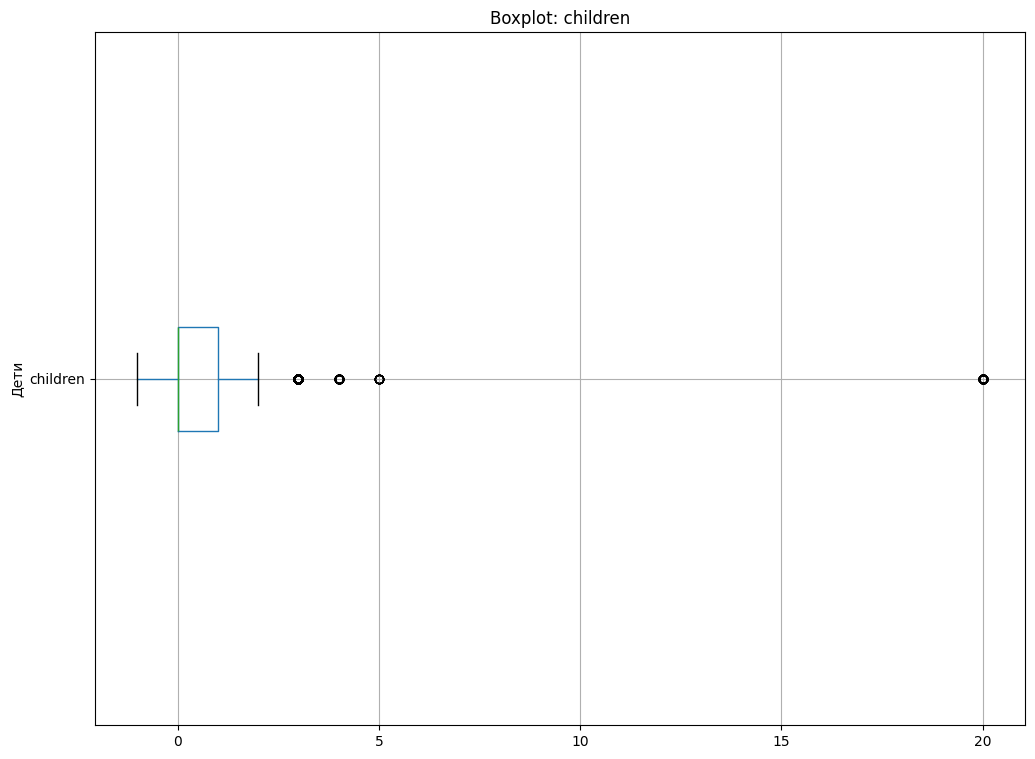

In [23]:
# Задаем размер графика
plt.figure(figsize=(12, 9))

# Строим график "ящик с усами"
df.boxplot(column='children',
           vert=False,
           grid=True
           )

# Настраиваем оформление графика
plt.title('Boxplot: children')
plt.ylabel('Дети')

# Выводим визуализированные данные
plt.show()

**Вывод:**

- Медиана находится близко к нижней границе ящика, что свидетельствует о правосторонней асимметрии распределения количества детей в выборке. Это означает, что большая часть наблюдений характеризуется небольшим числом детей (преимущественно 0–1 ребёнок).

- За верхним усом наблюдается несколько выбросов, которые значительно превышают типичный диапазон.

- Особенно выделяется экстремальный выброс вблизи отметки 20 — крайне редкое значение, которое может быть либо
реальным случаем многодетной семьи, либо ошибкой ввода данных

In [24]:
Q1 = df['children'].quantile(0.25)
Q3 = df['children'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f'Q1: {Q1:,.2f}')
print(f'Q3: {Q3:,.2f}')
print(f'IQR: {IQR:,.2f}')
print(f'Нижняя граница выбросов: {lower_bound:,.2f}')
print(f'Верхняя граница выбросов: {upper_bound:,.2f}')

outliers = df[(df['children'] < lower_bound) | (df['children'] > upper_bound)]
print(f'Количество выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')

Q1: 0.00
Q3: 1.00
IQR: 1.00
Нижняя граница выбросов: -1.50
Верхняя граница выбросов: 2.50
Количество выбросов: 453 (2.12%)


**Вывод:**

- Нижняя граница выбросов отрицательна (–1,5), что указывает на наличие некорректных значений. Отрицательное количество детей невозможно — это технические ошибки ввода.

- Верхняя граница выбросов равна 2,5. Все значения 3 и более формально попадают в разряд выбросов по методу IQR, но такие значения являются допустимыми и реалистичными

- Доля выбросов составляет 2,12% (453 записи). Однако эта доля складывается из двух качественно разных групп: ошибочные отрицательные значения и корректные значения ≥3

**Детальный анализ состава выбросов**

In [25]:
# Подсчёт отрицательных значений и значений ≥3
neg_count = (df['children'] < 0).sum()
high_count = (df['children'] > 2.5).sum()
print(f'Отрицательные значения: {neg_count}')
print(f'Значения 3 и более: {high_count}')

Отрицательные значения: 47
Значения 3 и более: 453


**Вывод:**

- Общее количество выбросов по методу IQR: 453 — это означает, что все выбросы пришлись на значения ≥3, а отрицательные значения не являются выбросами согласно расчёту

### Решение по выбросам в столбце `children`:

1. Удалить все строки с отрицательными значениями 

2. Сохранить все записи со значениями ≥3, но удалить строки, где значение равно 20

In [26]:
# Удалим отрицательные значения
df = df[df['children'] >= 0]

In [27]:
df = df[df['children'] != 20]

## 4. Добавление новых столбцов в таблицу

In [28]:
# Создаём пустой столбец категорий
df['income_category'] = np.nan
df['income_category'] = df['income_category'].astype(object)

In [29]:
# Категория "Без дохода"
df.loc[(df['total_income'] == 0) & (df['income_type'] == 'unemployed'), 'income_category'] = 'Без дохода'

In [30]:
# Процентили по полному распределению
p14 = df['total_income'].quantile(0.14)
p34 = df['total_income'].quantile(0.34)
p78 = df['total_income'].quantile(0.78)


In [31]:
# Границы и метки для оставшихся 4 категорий
bins = [-np.inf, p14, p34, p78, np.inf]
labels = ['Очень низкий доход', 'Низкий доход', 'Средний доход', 'Высокий доход']

In [32]:
# Назначаем категории для всех, кто ещё не получил "Без дохода"
mask = df['income_category'].isna()
df.loc[mask, 'income_category'] = pd.cut(df.loc[mask, 'total_income'], bins=bins, labels=labels, right=False)

In [33]:
# Проверка
print(df['income_category'].value_counts())

income_category
Средний доход         9341
Высокий доход         4671
Низкий доход          4246
Очень низкий доход    2973
Name: count, dtype: int64


In [34]:
# Сначала устанавливаем категорию по умолчанию для всех
df['age_category'] = 'после 40 лет'

# Затем для возраста до 40 лет меняем категорию
df.loc[df['dob_years'] < 40, 'age_category'] = 'до 40 лет'

In [35]:
# Проверка
print(df['age_category'].value_counts())

age_category
после 40 лет    12440
до 40 лет        8791
Name: count, dtype: int64


In [36]:
# Границы и метки для категорий
bins = [-1, 0, 2, np.inf] 
labels = ['без детей', 'от одного до двух', 'от трёх и больше']
df['children_category'] = pd.cut(df['children'], bins=bins, labels=labels, right=True)

In [37]:
# Проверка
print(df['children_category'].value_counts())

children_category
без детей            14022
от одного до двух     6831
от трёх и больше       378
Name: count, dtype: int64


## 5. Исследовательский анализ данных

**Фактор: `income_category`**

In [38]:
# Сводная таблица 
summary = pd.pivot_table(
        df,
        index='income_category',
        values='debt',
        aggfunc={'debt': ['count', 'sum']}
    )
summary.columns = ['Всего', 'Должники']

summary['Доля_должников_%'] = (summary['Должники'] / summary['Всего']) * 100

summary = summary.sort_values('Доля_должников_%', ascending=False)

print(summary)

                    Всего  Должники  Доля_должников_%
income_category                                      
Средний доход        9341       807          8.639332
Низкий доход         4246       361          8.502120
Очень низкий доход   2973       229          7.702657
Высокий доход        4671       327          7.000642


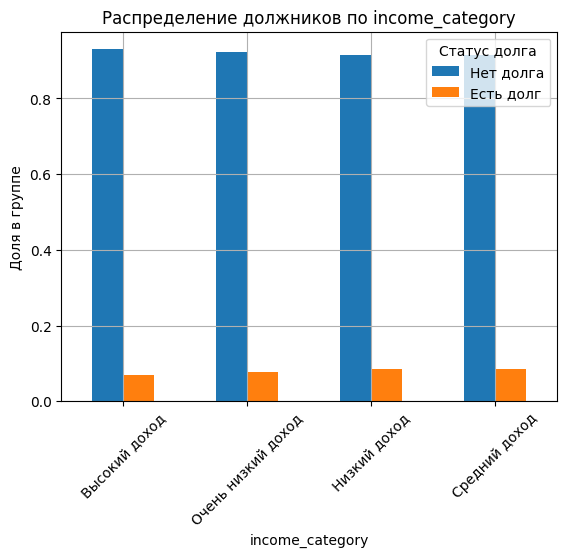

In [39]:
# Разделяем данные на две группы: без долга (debt=0) и с долгом (debt=1)
no_debt = df[df['debt'] == 0]
has_debt = df[df['debt'] == 1]

# Считаем количество клиентов в каждой группе по factor
no_debt_count = no_debt['income_category'].value_counts()
has_debt_count = has_debt['income_category'].value_counts()

# Объединяем данные в один DataFrame
debt_comparison = pd.concat([no_debt_count, has_debt_count], axis=1)

# Переименовываем столбцы
debt_comparison.columns = ['Нет долга', 'Есть долг']

# Заполняем NaN нулями
debt_comparison = debt_comparison.fillna(0)

debt_norm = debt_comparison.div(debt_comparison.sum(axis=1), axis=0)


# Визуализация
debt_norm.sort_values(by='Нет долга', ascending=False).plot(kind='bar',
                                                                      rot=45
                                                                      )
    
plt.title('Распределение должников по income_category')
plt.xlabel('income_category')
plt.ylabel('Доля в группе')
plt.legend(title='Статус долга')
plt.grid()

plt.show()

**Вывод:**

- Анализ показал, что доля должников относительно невелика во всех категориях дохода (в диапазоне 7–8,6%), однако существуют различия между группами.

- Наибольшая доля должников — в категории «Средний доход»

     - Доля должников: 8,64% (807 из 9 341 клиента).
     - Это самая высокая доля среди всех категорий

- Сравнительно высокая задолженность у клиентов с низким доходом

    - Доля должников: 8,50% (361 из 4 246 клиентов).
    - Клиенты с низким доходом демонстрируют практически идентичный с «средним доходом» уровень риска.

- Относительно низкая задолженность у клиентов с очень низким доходом

    - Доля должников: 7,70% (229 из 2 973 клиентов).
    - Несмотря на низкий уровень дохода, доля должников немного ниже, чем в «средней» и «низкой» категориях

- Наименьшая доля должников — у клиентов с высоким доходом

    - Доля должников: 7,00% (327 из 4 671 клиента).
    - Эта категория демонстрирует наименьший кредитный риск

**Фактор: `education`**

In [40]:
summary = pd.pivot_table(
        df,
        index='education',
        values='debt',
        aggfunc={'debt': ['count', 'sum']}
    )
summary.columns = ['Всего', 'Должники']

summary['Доля_должников_%'] = (summary['Должники'] / summary['Всего']) * 100

summary = summary.sort_values('Доля_должников_%', ascending=False)

print(summary)


                     Всего  Должники  Доля_должников_%
education                                             
primary education      282        31         10.992908
some college           739        68          9.201624
secondary education  15012      1348          8.979483
bachelor's degree     5192       277          5.335131
graduate degree          6         0          0.000000


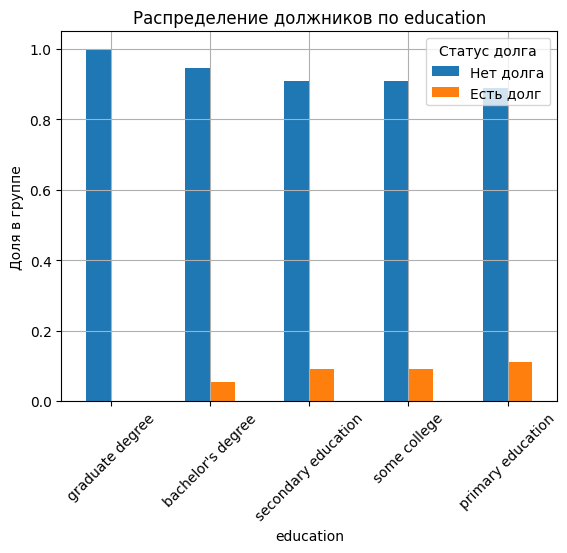

In [41]:
# Разделяем данные на две группы: без долга (debt=0) и с долгом (debt=1)
no_debt = df[df['debt'] == 0]
has_debt = df[df['debt'] == 1]

# Считаем количество клиентов в каждой группе по factor
no_debt_count = no_debt['education'].value_counts()
has_debt_count = has_debt['education'].value_counts()

# Объединяем данные в один DataFrame
debt_comparison = pd.concat([no_debt_count, has_debt_count], axis=1)

# Переименовываем столбцы
debt_comparison.columns = ['Нет долга', 'Есть долг']

# Заполняем NaN нулями
debt_comparison = debt_comparison.fillna(0)

debt_norm = debt_comparison.div(debt_comparison.sum(axis=1), axis=0)


# Визуализация
debt_norm.sort_values(by='Нет долга', ascending=False).plot(kind='bar',
                                                                      rot=45
                                                                      )
    
plt.title('Распределение должников по education')
plt.xlabel('education')
plt.ylabel('Доля в группе')
plt.legend(title='Статус долга')
plt.grid()

plt.show()

**Вывод:**

- Анализ подтвердил, что чем выше уровень образования, тем ниже доля должников. Это наглядно отражено как в сводной таблице, так и на столбчатой диаграмме.

- Наиболее рискованная группа — клиенты с начальным образованием («primary education»)

- Разрыв между самой высокорискованной («primary education», 10,99%) и самой низкорискованной («graduate degree», 0%) группой составляет 10,99 процентных пунктов. Это подчёркивает значимость образования как фактора кредитного риска.

**Фактор: `age_category`**

In [42]:
summary = pd.pivot_table(
        df,
        index='age_category',
        values='debt',
        aggfunc={'debt': ['count', 'sum']}
    )
summary.columns = ['Всего', 'Должники']

summary['Доля_должников_%'] = (summary['Должники'] / summary['Всего']) * 100

summary = summary.sort_values('Доля_должников_%', ascending=False)

print(summary)

              Всего  Должники  Доля_должников_%
age_category                                   
до 40 лет      8791       897         10.203617
после 40 лет  12440       827          6.647910


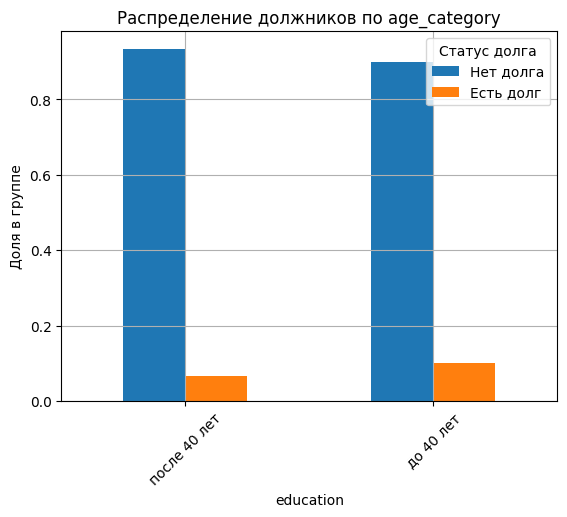

In [43]:
# Разделяем данные на две группы: без долга (debt=0) и с долгом (debt=1)
no_debt = df[df['debt'] == 0]
has_debt = df[df['debt'] == 1]

# Считаем количество клиентов в каждой группе по factor
no_debt_count = no_debt['age_category'].value_counts()
has_debt_count = has_debt['age_category'].value_counts()

# Объединяем данные в один DataFrame
debt_comparison = pd.concat([no_debt_count, has_debt_count], axis=1)

# Переименовываем столбцы
debt_comparison.columns = ['Нет долга', 'Есть долг']

# Заполняем NaN нулями
debt_comparison = debt_comparison.fillna(0)

debt_norm = debt_comparison.div(debt_comparison.sum(axis=1), axis=0)


# Визуализация
debt_norm.sort_values(by='Нет долга', ascending=False).plot(kind='bar',
                                                                      rot=45
                                                                      )
    
plt.title('Распределение должников по age_category')
plt.xlabel('education')
plt.ylabel('Доля в группе')
plt.legend(title='Статус долга')
plt.grid()

plt.show()

**Вывод:**

- На графике чётко видно, что доля клиентов без долга значительно превышает долю должников как среди клиентов младше 40 лет, так и среди клиентов старше 40 лет.

- По результатам сводной таблицы выявлены следующие доли должников:
    - клиенты до 40 лет — 10,20% (897 должников из 8 791 клиента);
    - клиенты после 40 лет — 6,65% (827 должников из 12 440 клиентов).

- Клиенты в возрастной группе «до 40 лет» демонстрируют значительно более высокую долю должников по сравнению с группой «после 40 лет».

**Фактор: `children_category`**

In [44]:
# Сводная таблица 
summary = pd.pivot_table(
        df,
        index='children_category',
        values='debt',
        aggfunc={'debt': ['count', 'sum']},
        observed=False
    )
summary.columns = ['Всего', 'Должники']

summary['Доля_должников_%'] = (summary['Должники'] / summary['Всего']) * 100

summary = summary.sort_values('Доля_должников_%', ascending=False)

print(summary)

                   Всего  Должники  Доля_должников_%
children_category                                   
от одного до двух   6831       635          9.295857
от трёх и больше     378        31          8.201058
без детей          14022      1058          7.545286


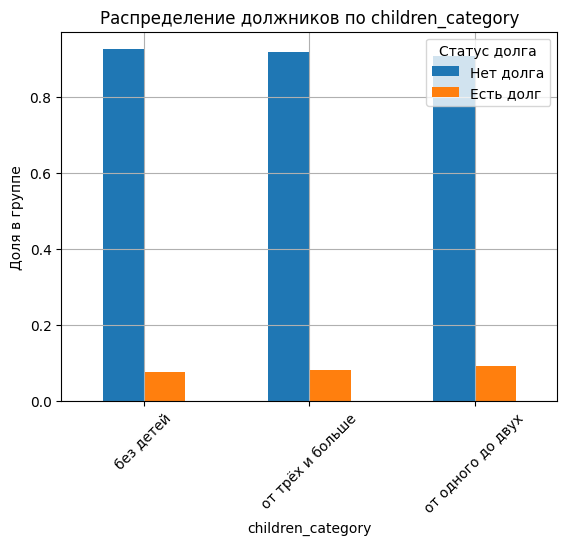

In [45]:
# Разделяем данные на две группы: без долга (debt=0) и с долгом (debt=1)
no_debt = df[df['debt'] == 0]
has_debt = df[df['debt'] == 1]

# Считаем количество клиентов в каждой группе по factor
no_debt_count = no_debt['children_category'].value_counts()
has_debt_count = has_debt['children_category'].value_counts()

# Объединяем данные в один DataFrame
debt_comparison = pd.concat([no_debt_count, has_debt_count], axis=1)

# Переименовываем столбцы
debt_comparison.columns = ['Нет долга', 'Есть долг']

# Заполняем NaN нулями
debt_comparison = debt_comparison.fillna(0)

debt_norm = debt_comparison.div(debt_comparison.sum(axis=1), axis=0)


# Визуализация
debt_norm.sort_values(by='Нет долга', ascending=False).plot(kind='bar',
                                                                      rot=45
                                                                      )
    
plt.title('Распределение должников по children_category')
plt.xlabel('children_category')
plt.ylabel('Доля в группе')
plt.legend(title='Статус долга')
plt.grid()

plt.show()

**Вывод:**

- На графике и в сводной таблице чётко видно, что большинство клиентов в каждой категории не имеют долга.

- По результатам анализа выявлены следующие доли должников в процентах:
    - «от одного до двух детей» — 9,29%;
    - «от трёх и больше детей» — 8,20%;
    - «без детей» — 7,55%.

- Категория «без детей» демонстрирует наименьшую долю должников (7,55%)

- Хотя доля должников растёт с увеличением числа детей, рост не является существенным. Это говорит о том, что наличие детей не является критическим фактором риска невозврата кредита

- Доли должников в трёх категориях сравнительно близки. Это указывает на то, что количество детей — не определяющий фактор при формировании группы должников

**Проверка исследовательской гипотезы №1**

In [46]:
# Создаем функцию для создания нового столбца is_children
def categories_children(children):
    # Проверяем, есть ли пропущенные значения
    if pd.isna(children):
        return False

    # Проверяем условие
    if children > 0:
        return 1
    else:
        return 0

# Создаем новый столбец
df['is_children'] = df['children'].apply(categories_children)

In [47]:
# Выводим первые 5 значений нового столбца
df['is_children'].head()

0    1
1    1
2    0
3    1
4    0
Name: is_children, dtype: int64

In [48]:
# Расчёт доли просрочек для каждой группы
debt_rate = df.groupby('is_children')['debt'].mean()
print("Доля просрочек:")
print(debt_rate)

# Перевод в проценты
debt_rate_percent = debt_rate * 100
print("Доля просрочек в процентах:")
print(debt_rate_percent)

Доля просрочек:
is_children
0    0.075453
1    0.092385
Name: debt, dtype: float64
Доля просрочек в процентах:
is_children
0    7.545286
1    9.238452
Name: debt, dtype: float64


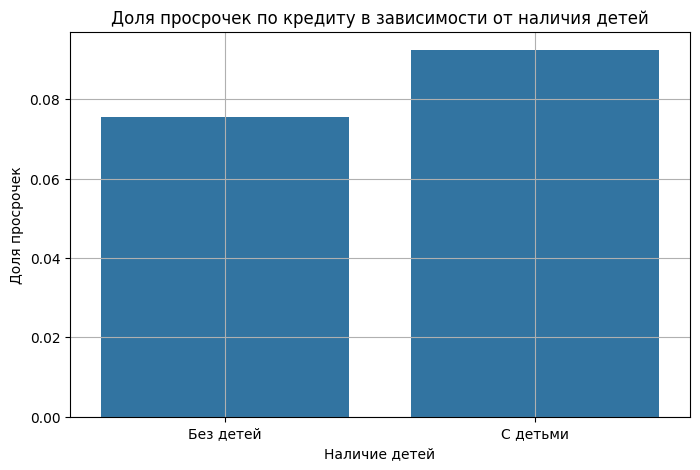

In [49]:
plt.figure(figsize=(8, 5))
sns.barplot(x=debt_rate.index, y=debt_rate.values)

plt.xticks([0, 1], ['Без детей', 'С детьми'])
plt.title('Доля просрочек по кредиту в зависимости от наличия детей')
plt.xlabel('Наличие детей')
plt.ylabel('Доля просрочек')
plt.grid()
plt.show()


**Вывод:**

Полученные данные опровергают исходную гипотезу. Вместо снижения риска просрочек у клиентов с детьми наблюдается обратная тенденция — риск выше (9,24% против 7,55%)

**Проверка исследовательской гипотезы №2**

In [50]:
# Фильтрация только мужчин
df_men = df[df['gender'] == 'M'].copy()

In [51]:
# Семейные (married, civil partnership)
df_men['family'] = df_men['family_status_id'].isin([0, 1]).astype(int)

# Одинокие (widow/widower, divorced, unmarried)
df_men['single'] = df_men['family_status_id'].isin([2, 3, 4]).astype(int)


In [52]:
df_men['low_income'] = (df_men['income_category'] == 'Низкий доход').astype(int)
df_men['medium_income'] = (df_men['income_category'] == 'Средний доход').astype(int)

In [53]:
# Группа 1: одинокие мужчины с низким доходом
G1 = df_men[(df_men['single'] == 1) & (df_men['low_income'] == 1)]['debt']

# Группа 2: семейные мужчины со средним доходом
G2 = df_men[(df_men['family'] == 1) & (df_men['medium_income'] == 1)]['debt']


In [54]:
debt_rate_G1 = G1.mean()
debt_rate_G2 = G2.mean()

print(f"Доля должников (одинокие, низкий доход): {debt_rate_G1:.3f}")
print(f"Доля должников (семейные, средний доход): {debt_rate_G2:.3f}")


Доля должников (одинокие, низкий доход): 0.152
Доля должников (семейные, средний доход): 0.105


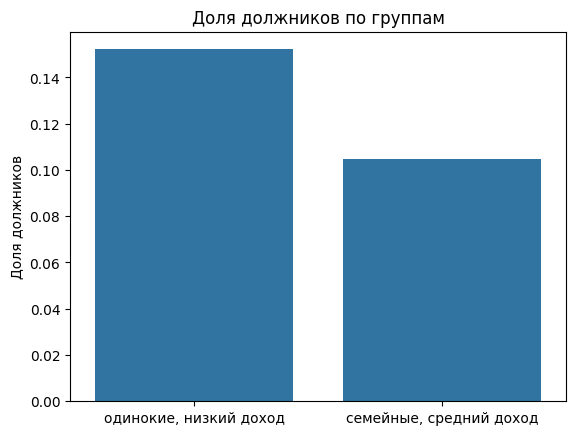

In [55]:
sns.barplot(x=['одинокие, низкий доход', 'семейные, средний доход'],
            y=[debt_rate_G1, debt_rate_G2])
plt.title('Доля должников по группам')
plt.ylabel('Доля должников')
plt.show()

**Вывод:**

Гипотеза подтверждается — одинокие мужчины с низким доходом действительно чаще оказываются должниками по сравнению с семейными мужчинами со средним доходом (15,2% против 10,5%).

## 6. Итоговый вывод

В ходе анализа данных о заёмщиках банка «Скрудж» выявлены ключевые закономерности, позволяющие оценить факторы кредитного риска и сформировать основу для модели скоринга.

- **1. Влияние уровня дохода на платёжную дисциплину**

    - Хотя доля должников во всех доходных категориях остаётся относительно невысокой (7–8,6 %), обнаружены значимые различия между группами:

        - Наибольший риск — в категории «Средний доход» (8,64 % должников)

- **2. Роль уровня образования**

    - Образование — значимый фактор платёжной дисциплины:

        - Максимальная доля должников — среди клиентов с начальным образованием (10,99 %);

        - Минимальная — у обладателей учёной степени (0 %).

- **3. Возрастные особенности**

    - Возраст существенно влияет на кредитный риск:

        - Клиенты до 40 лет — 10,20 % должников;

        - Клиенты после 40 лет — 6,65 % должников.

- **4. Влияние количества детей**

    - Гипотеза о снижении риска у клиентов с детьми не подтвердилась. Хотя рост доли должников с увеличением числа детей наблюдается, он не является критическим. Категория «без детей» демонстрирует наименьший риск.

- **5. Семейное положение и доход**

    - одинокие мужчины с низким доходом чаще становятся должниками, что делает их высокорискованной группой